### Improving grpo for reinforcement learning--->  rlvr

In [1]:
from pathlib import Path
import sys
import torch

ROOT_DIR = Path.cwd().parent  # Get parent of current directory
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))


from evaluating_reasoning_models.model_and_tokenizer import load_model_and_tokenizer

model, tokenizer = load_model_and_tokenizer(
    which_model="base",
    use_compile=False,
    load_rlvr_checkpoint=True
)



Loading RLVR checkpoint: /teamspace/studios/this_studio/open-posttraining-system/qwen/qwen3-0.6B-rlvr-grpo-step00050.safetensors
Loaded 311 tensors
Missing keys: 0
Unexpected keys: 0


#### downloading previous chapter notebook

In [2]:
from pathlib import Path
import requests


def download_from_github(rel_path, out=None):

    github_raw_base = (
        "https://raw.githubusercontent.com/"
        "shaheennabi/open-posttraining-system/main/"
    )

    rel_path = Path(rel_path)

    out = Path(out) if out is not None else Path(rel_path.name)

    if out.exists():
        print(f"{out} already exists")
        return out

    r = requests.get(
        github_raw_base + rel_path.as_posix()
    )
    r.raise_for_status()

    out.write_bytes(r.content)

    print(f"Downloaded {out}")

    return out

In [3]:
download_from_github(
    "training_reasoning_models_with_reinforcement_learning/rlvr_grpo_training_with_no_kl.py"
)

rlvr_grpo_training_with_no_kl.py already exists


PosixPath('rlvr_grpo_training_with_no_kl.py')

In [4]:
### rlvr_grpo training run
!uv run rlvr_grpo_training_with_no_kl.py --steps 500 --max_new_tokens 1024

   Building open-posttraining-system @ file:///teamspace/studios/this_studio/opem Preparing packages... (0/0)                                                   
   Building open-posttraining-system @ file:///teamspace/studios/this_studio/ope
   Building open-posttraining-system @ file:///teamspace/studios/this_studio/ope
   Building open-posttraining-system @ file:///teamspace/studios/this_studio/ope
   Building open-posttraining-system @ file:///teamspace/studios/this_studio/ope
   Building open-posttraining-system @ file:///teamspace/studios/this_studio/ope
   Building open-posttraining-system @ file:///teamspace/studios/this_studio/ope
      Built open-posttraining-system @ file:///teamspace/studios/this_studio/ope
Uninstalled 1 package in 1ms                                             
Installed 1 package in 1msystem==0.1.0 (from file:///teamspa
Traceback (most recent call last):
  File "/teamspace/studios/this_studio/open-posttraining-system/improving_grpo_for_reinforcement_learn

In [4]:
## log file (download from previous chapter)
download_from_github(
    "training_reasoning_models_with_reinforcement_learning/train_rlvr_grpo_metrics.csv"
)

train_rlvr_grpo_metrics.csv already exists


PosixPath('train_rlvr_grpo_metrics.csv')

In [5]:
import pandas as pd

df = pd.read_csv(
    "train_rlvr_grpo_metrics.csv",
    header=None,
    names=[
        "step",
        "eval_freq",
        "loss",
        "reward_avg",
        "avg_response_len",
    ],
)

print(df.head())

   step  eval_freq      loss  reward_avg  avg_response_len
0     1         50 -0.000000        0.00           297.375
1     2         50 -0.000000        0.00           289.000
2     3         50 -0.000000        1.00           178.625
3     4         50 -0.000000        1.00           146.250
4     5         50 -2.021993        0.25           187.750


#### Inspecting the grpo training run (from sebastian raschka's notebook)

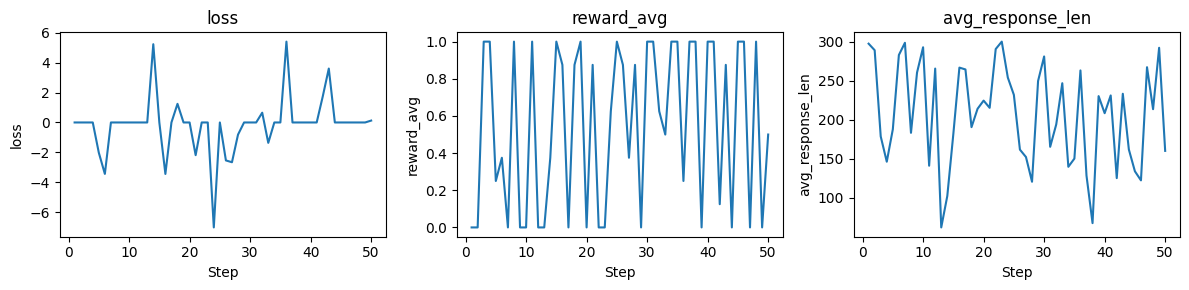

In [6]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv(
    "train_rlvr_grpo_metrics.csv",
    header=None,
    names=[
        "step",
        "eval_freq",
        "loss",
        "reward_avg",
        "avg_response_len",
    ],
)

fig, axes = plt.subplots(1, 3, figsize=(12, 3))

metrics = [
    "loss",
    "reward_avg",
    "avg_response_len",
]

for ax, metric in zip(axes, metrics):
    ax.plot(df["step"], df[metric])
    ax.set_title(metric)
    ax.set_xlabel("Step")
    ax.set_ylabel(metric)

plt.tight_layout()
plt.show()

In [7]:
from evaluating_reasoning_models.load_math_500 import load_math500_test
eval_data = load_math500_test()

In [8]:
import csv
from pathlib import Path


def log_eval_metrics(
    step,
    num_correct,
    num_examples,
    acc,
    csv_path="eval_metrics.csv",
):
    csv_exists = Path(csv_path).exists()

    with open(csv_path, "a", newline="") as f:
        writer = csv.writer(f)

        if not csv_exists:
            writer.writerow(
                [
                    "step",
                    "eval_acc",
                    "num_correct",
                    "num_examples",
                ]
            )

        writer.writerow(
            [
                step,
                round(acc, 4),
                num_correct,
                num_examples,
            ]
        )

    print(f"Logged evaluation to {csv_path}")

In [9]:
## ### on rlvr_grpo checkpoint(8 rollouts  ---> 50 steps)--> 
from evaluating_reasoning_models.evaluating_reasoning_models import evaluate_math500_stream

math_eval = eval_data[:50]  ## last 50 problems of math_dataset...

device = "cuda" if torch.cuda.is_available() else "cpu"
## evaluation function
num_correct, num_examples, acc = evaluate_math500_stream(model, tokenizer, device, math_eval, max_new_tokens=2048, verbose=False)



log_eval_metrics(
    step=50,
    num_correct=num_correct,
    num_examples=num_examples,
    acc=acc,
)

Progress: 50/50 | ETA: 00s        

Accuracy: 40.0% (20/50)
Total time: 6.8 minutes
Average response length: 255.1 tokens
Results saved to: math500-cuda.jsonl
Logged evaluation to eval_metrics.csv


### Tracking more advanced Grpo performance metrics

* Advantage tracking

* Entropy tracking